# Q3: Predictive Analytics — From Intake Profiles to Expected Service Demand

This notebook predicts trajectory cluster membership for 35 waitlisted children using only intake features, then estimates capacity demand under a differentiated reassessment policy.

**Pipeline:**
1. Reproduce the Q2 clustering to obtain cluster labels for the 77 historical clients
2. Explore intake features by trajectory cluster (Part a)
3. Train and evaluate two classifiers (Part b)
4. Predict waitlist trajectory mix and estimate capacity demand (Part c)

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

In [14]:
# Load data
scored = pd.read_csv('../q1/scored_notes.csv')
features = pd.read_csv('../data/client_features.csv')
waitlist = pd.read_csv('../data/waitlist.csv')

# Filter to valid C_ clients only (same as Q2)
scored = scored[scored['client_id'].str.startswith('C_')].copy()

print(f"Scored notes: {len(scored)} rows, {scored['client_id'].nunique()} clients")
print(f"Sessions: {sorted(scored['session'].unique())}")
print(f"\nClient features: {len(features)} rows")
print(f"Waitlist: {len(waitlist)} clients")

Scored notes: 847 rows, 77 clients
Sessions: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]

Client features: 117 rows
Waitlist: 35 clients


## Reproducing Q2 Clustering Pipeline

We first reproduce the Q2 K-means clustering (K=4, random_state=42, n_init=20) on cumulative progress trajectories to obtain cluster labels for the 77 historical clients.

In [15]:
# Build cumulative progress trajectories (reproducing Q2)
trajectories = {}
for cid, grp in scored.groupby('client_id'):
    grp = grp.sort_values('session')
    scores = grp['score'].values  # 11 transition scores (sessions 2-12)
    cumtraj = np.concatenate([[0], np.cumsum(scores)])  # 12-point trajectory
    trajectories[cid] = cumtraj

client_ids = sorted(trajectories.keys())
traj_matrix = np.array([trajectories[cid] for cid in client_ids])

# K-Means K=4 (same parameters as Q2)
FINAL_K = 4
km = KMeans(n_clusters=FINAL_K, random_state=42, n_init=20)
labels_raw = km.fit_predict(traj_matrix)

# Sort clusters by ascending final cumulative score (same as Q2)
cluster_order = np.argsort([km.cluster_centers_[c][-1] for c in range(FINAL_K)])
label_map = {old: new for new, old in enumerate(cluster_order)}
final_labels = np.array([label_map[l] for l in labels_raw])
final_centers = km.cluster_centers_[cluster_order]

# Create dataframe of client -> cluster label
labels_df = pd.DataFrame({'client_id': client_ids, 'cluster': final_labels})

print(f"Trajectory matrix shape: {traj_matrix.shape}")
for c in range(FINAL_K):
    n = np.sum(final_labels == c)
    print(f"Cluster {c}: n={n}, final cumulative = {final_centers[c][-1]:.1f}")

Trajectory matrix shape: (77, 12)
Cluster 0: n=21, final cumulative = 7.5
Cluster 1: n=21, final cumulative = 9.8
Cluster 2: n=27, final cumulative = 11.5
Cluster 3: n=8, final cumulative = 13.9


In [16]:
# Reproduce Q2 newsvendor policy: compute t* and Q* per cluster
Tmax = 12

def compute_t_star(traj, threshold_pct=0.90):
    """Find earliest session where cumulative >= threshold_pct * total."""
    total = traj[-1]
    if total == 0:
        return Tmax
    threshold = threshold_pct * total
    for s in range(len(traj)):
        if traj[s] >= threshold:
            return s + 1  # convert 0-indexed to 1-indexed session number
    return Tmax

t_star_array = np.array([compute_t_star(traj_matrix[i]) for i in range(len(client_ids))])

# Compute Q* and E[delivered] per cluster
cluster_policy = {}
for c in range(FINAL_K):
    mask = final_labels == c
    t_stars_c = t_star_array[mask]

    savings_by_Q = []
    for Q in range(1, Tmax + 1):
        Fc_Q = np.mean(t_stars_c <= Q)
        savings_by_Q.append(Fc_Q * (Tmax - Q))

    Q_star = np.argmax(savings_by_Q) + 1
    E_savings = savings_by_Q[Q_star - 1]
    Fc_Qstar = np.mean(t_stars_c <= Q_star)
    E_delivered = Fc_Qstar * Q_star + (1 - Fc_Qstar) * Tmax

    cluster_policy[c] = {
        'Q_star': Q_star,
        'E_savings': E_savings,
        'Fc_Qstar': Fc_Qstar,
        'E_delivered': E_delivered,
        'n': int(mask.sum())
    }
    print(f"Cluster {c}: Q*={Q_star}, F_c(Q*)={Fc_Qstar:.2f}, "
          f"E[delivered]={E_delivered:.2f}, E[savings]={E_savings:.2f}")

CLUSTER_LABELS = {
    0: 'Low-Gain / Early Plateau',
    1: 'Moderate-Gain / Steady Improver',
    2: 'High-Gain / Strong Responder',
    3: 'Very High-Gain / Rapid Progressor'
}

Cluster 0: Q*=7, F_c(Q*)=0.71, E[delivered]=8.43, E[savings]=3.57
Cluster 1: Q*=8, F_c(Q*)=0.86, E[delivered]=8.57, E[savings]=3.43
Cluster 2: Q*=8, F_c(Q*)=0.96, E[delivered]=8.15, E[savings]=3.85
Cluster 3: Q*=8, F_c(Q*)=0.88, E[delivered]=8.50, E[savings]=3.50


## Part (a): Exploring Intake Features by Trajectory Type

We merge the cluster labels with intake features from `client_features.csv` to examine how age, complexity, referral reason, and gender differ across the four trajectory clusters.

In [17]:
# Merge cluster labels with client features
merged = labels_df.merge(features, on='client_id')
merged['cluster_label'] = merged['cluster'].map(CLUSTER_LABELS)

print(f"Merged dataset: {len(merged)} clients with features + cluster labels")
print(f"\nCluster distribution:")
print(merged.groupby(['cluster', 'cluster_label']).size().reset_index(name='count').to_string(index=False))
print(f"\nFeature summary:")
print(merged[['age_years', 'complexity_score']].describe().round(2))

Merged dataset: 77 clients with features + cluster labels

Cluster distribution:
 cluster                     cluster_label  count
       0          Low-Gain / Early Plateau     21
       1   Moderate-Gain / Steady Improver     21
       2      High-Gain / Strong Responder     27
       3 Very High-Gain / Rapid Progressor      8

Feature summary:
       age_years  complexity_score
count      77.00             77.00
mean        2.67              4.35
std         0.68              1.23
min         1.35              1.00
25%         2.23              4.00
50%         2.65              5.00
75%         3.08              5.00
max         4.08              5.00


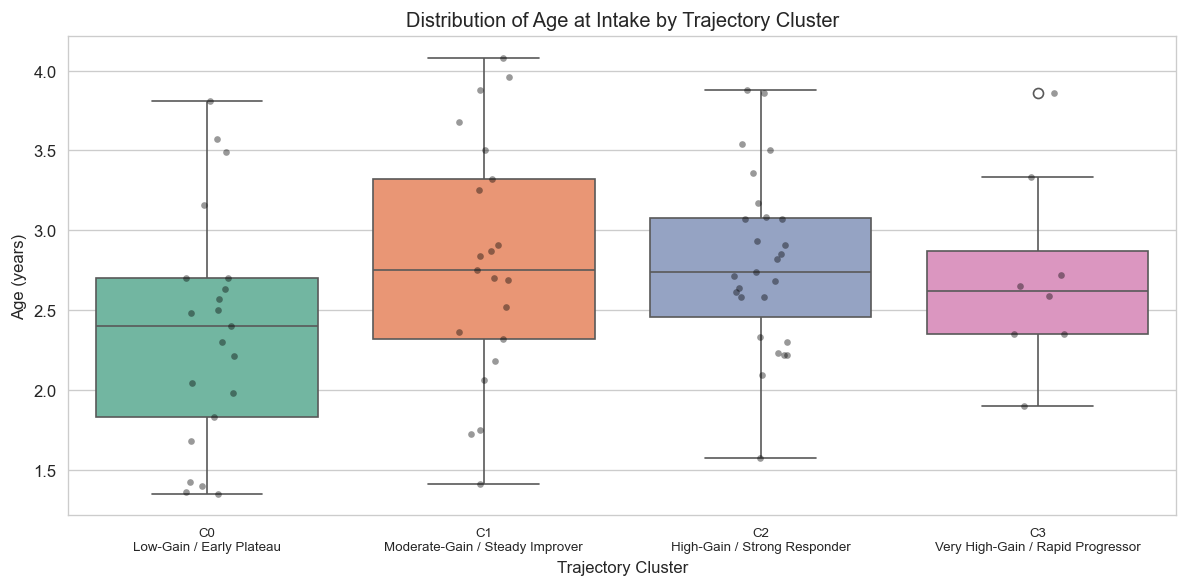


Age statistics by cluster:
         count  mean   std   min   25%   50%   75%   max
cluster                                                 
0         21.0  2.36  0.73  1.35  1.83  2.40  2.70  3.81
1         21.0  2.80  0.76  1.41  2.32  2.75  3.32  4.08
2         27.0  2.80  0.54  1.57  2.46  2.74  3.08  3.88
3          8.0  2.72  0.61  1.90  2.35  2.62  2.87  3.86


In [18]:
# Age distribution by cluster
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=merged, x='cluster', y='age_years', palette='Set2', ax=ax)
sns.stripplot(data=merged, x='cluster', y='age_years',
              color='black', alpha=0.4, size=4, jitter=True, ax=ax)
ax.set_xlabel('Trajectory Cluster')
ax.set_ylabel('Age (years)')
ax.set_title('Distribution of Age at Intake by Trajectory Cluster')
labels_str = [f'C{c}\n{CLUSTER_LABELS[c]}' for c in range(FINAL_K)]
ax.set_xticklabels(labels_str, fontsize=8)
plt.tight_layout()
plt.show()

# Print per-cluster age statistics
print("\nAge statistics by cluster:")
print(merged.groupby('cluster')['age_years'].describe().round(2).to_string())

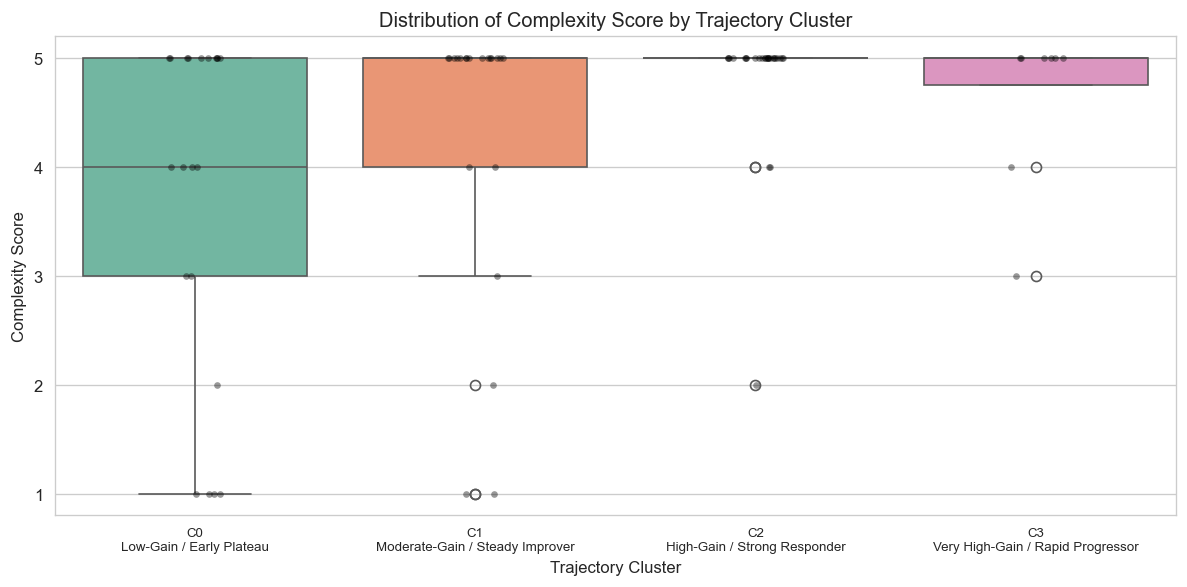


Complexity score statistics by cluster:
         count  mean   std  min   25%  50%  75%  max
cluster                                             
0         21.0  3.71  1.59  1.0  3.00  4.0  5.0  5.0
1         21.0  4.29  1.35  1.0  4.00  5.0  5.0  5.0
2         27.0  4.81  0.62  2.0  5.00  5.0  5.0  5.0
3          8.0  4.62  0.74  3.0  4.75  5.0  5.0  5.0


In [19]:
# Complexity score distribution by cluster
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=merged, x='cluster', y='complexity_score', palette='Set2', ax=ax)
sns.stripplot(data=merged, x='cluster', y='complexity_score',
              color='black', alpha=0.4, size=4, jitter=True, ax=ax)
ax.set_xlabel('Trajectory Cluster')
ax.set_ylabel('Complexity Score')
ax.set_title('Distribution of Complexity Score by Trajectory Cluster')
labels_str = [f'C{c}\n{CLUSTER_LABELS[c]}' for c in range(FINAL_K)]
ax.set_xticklabels(labels_str, fontsize=8)
ax.set_yticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()

# Print per-cluster complexity statistics
print("\nComplexity score statistics by cluster:")
print(merged.groupby('cluster')['complexity_score'].describe().round(2).to_string())

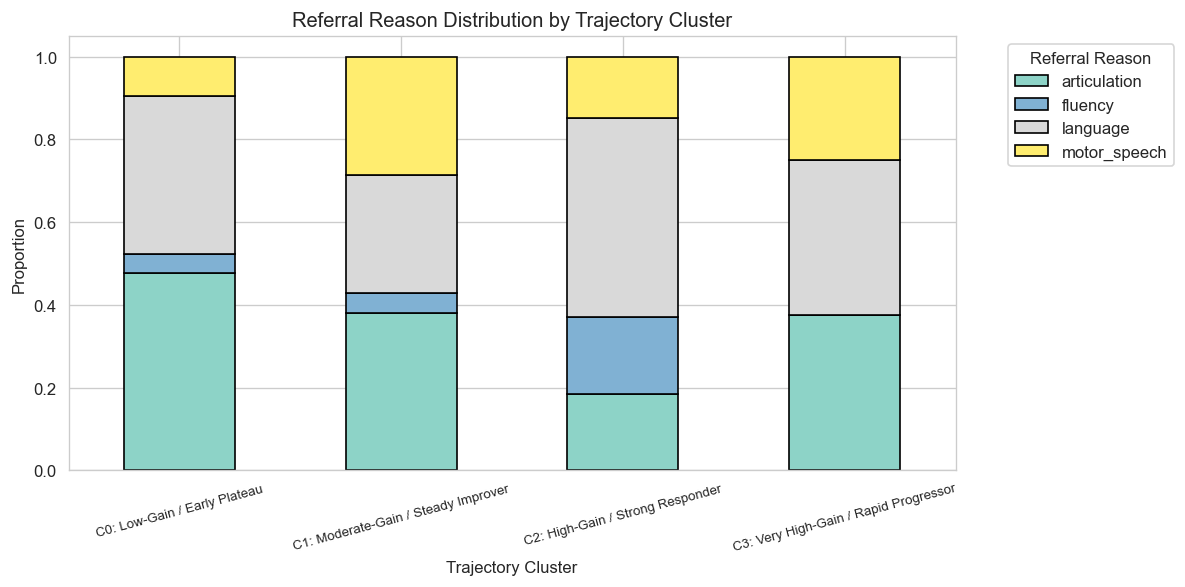


Referral reason counts by cluster:
referral_reason  articulation  fluency  language  motor_speech
cluster                                                       
0                          10        1         8             2
1                           8        1         6             6
2                           5        5        13             4
3                           3        0         3             2


In [20]:
# Referral reason distribution by cluster
fig, ax = plt.subplots(figsize=(10, 5))
ct = pd.crosstab(merged['cluster'], merged['referral_reason'], normalize='index')
ct.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='Set3', edgecolor='black', ax=ax)
ax.set_xlabel('Trajectory Cluster')
ax.set_ylabel('Proportion')
ax.set_title('Referral Reason Distribution by Trajectory Cluster')
ax.set_xticklabels([f'C{c}: {CLUSTER_LABELS[c]}' for c in range(FINAL_K)],
                    rotation=15, fontsize=8)
ax.legend(title='Referral Reason', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Print counts
print("\nReferral reason counts by cluster:")
print(pd.crosstab(merged['cluster'], merged['referral_reason']).to_string())

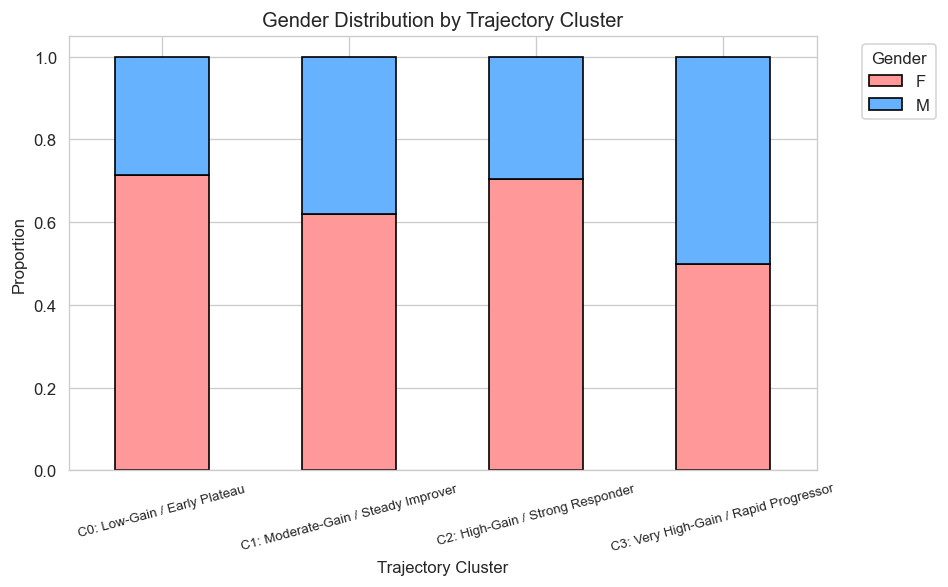


Gender counts by cluster:
gender    F  M
cluster       
0        15  6
1        13  8
2        19  8
3         4  4


In [21]:
# Gender distribution by cluster
fig, ax = plt.subplots(figsize=(8, 5))
ct_gender = pd.crosstab(merged['cluster'], merged['gender'], normalize='index')
ct_gender.plot(kind='bar', stacked=True, color=['#FF9999', '#66B2FF'],
               edgecolor='black', ax=ax)
ax.set_xlabel('Trajectory Cluster')
ax.set_ylabel('Proportion')
ax.set_title('Gender Distribution by Trajectory Cluster')
ax.set_xticklabels([f'C{c}: {CLUSTER_LABELS[c]}' for c in range(FINAL_K)],
                    rotation=15, fontsize=8)
ax.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Print counts
print("\nGender counts by cluster:")
print(pd.crosstab(merged['cluster'], merged['gender']).to_string())

### Part (a) Discussion

**Which features appear most useful for distinguishing trajectory groups?**

- **Complexity score** shows differentiation across clusters. The Low-Gain cluster (C0) has more diversity in complexity (values 1–5 represented), while the higher-gain clusters (C2, C3) are dominated by complexity score 5. Lower-complexity clients appear more concentrated in the Low-Gain cluster.
- **Age** shows modest differences across clusters. The Low-Gain cluster tends to include younger children on average, while higher-gain clusters skew slightly older. Age provides a weak but potentially useful signal.
- **Referral reason** shows some patterns: language-referred clients may be more prevalent in higher-gain clusters, while articulation referrals are more spread across clusters.

**Which features overlap substantially across groups?**

- **Gender** shows minimal differentiation — all clusters have similar gender proportions, making it a poor discriminator.
- **Age** and **referral reason** distributions overlap substantially across clusters despite showing some trends. The within-cluster variance is high relative to between-cluster differences.

With only 77 samples split across 4 classes (smallest class n=8), feature separation is inherently limited. However, **complexity score** and **age** appear to carry the most discriminative information for predicting trajectory group membership.

## Part (b): Train Two Classifiers to Predict Trajectory Group

We train two classifiers using intake features alone:
1. **Multinomial Logistic Regression** (parametric)
2. **Random Forest** (non-parametric)

**Features:** gender (one-hot), referral_reason (one-hot), age_years, complexity_score  
**Target:** cluster label (0–3)  
**Split:** stratified 80/20 train/test (random_state=42)

In [22]:
# Prepare feature matrix and target
X = pd.get_dummies(merged[['gender', 'referral_reason', 'age_years', 'complexity_score']],
                    columns=['gender', 'referral_reason'], drop_first=False)
y = merged['cluster'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Features: {list(X.columns)}")
print(f"\nTarget distribution:")
for c in range(FINAL_K):
    print(f"  Cluster {c} ({CLUSTER_LABELS[c]}): {np.sum(y == c)}")

Feature matrix shape: (77, 8)
Features: ['age_years', 'complexity_score', 'gender_F', 'gender_M', 'referral_reason_articulation', 'referral_reason_fluency', 'referral_reason_language', 'referral_reason_motor_speech']

Target distribution:
  Cluster 0 (Low-Gain / Early Plateau): 21
  Cluster 1 (Moderate-Gain / Steady Improver): 21
  Cluster 2 (High-Gain / Strong Responder): 27
  Cluster 3 (Very High-Gain / Rapid Progressor): 8


In [23]:
# Stratified 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} samples")
print(f"Test:  {len(X_test)} samples")
print(f"\nTrain class distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Test class distribution:  {dict(zip(*np.unique(y_test, return_counts=True)))}")

Train: 61 samples
Test:  16 samples

Train class distribution: {np.int64(0): np.int64(17), np.int64(1): np.int64(17), np.int64(2): np.int64(21), np.int64(3): np.int64(6)}
Test class distribution:  {np.int64(0): np.int64(4), np.int64(1): np.int64(4), np.int64(2): np.int64(6), np.int64(3): np.int64(2)}


=== Multinomial Logistic Regression ===
Test Accuracy: 0.375 (6/16)

Classification Report:
                                       precision    recall  f1-score   support

         C0: Low-Gain / Early Plateau       0.25      0.25      0.25         4
  C1: Moderate-Gain / Steady Improver       0.00      0.00      0.00         4
     C2: High-Gain / Strong Responder       0.50      0.83      0.62         6
C3: Very High-Gain / Rapid Progressor       0.00      0.00      0.00         2

                             accuracy                           0.38        16
                            macro avg       0.19      0.27      0.22        16
                         weighted avg       0.25      0.38      0.30        16



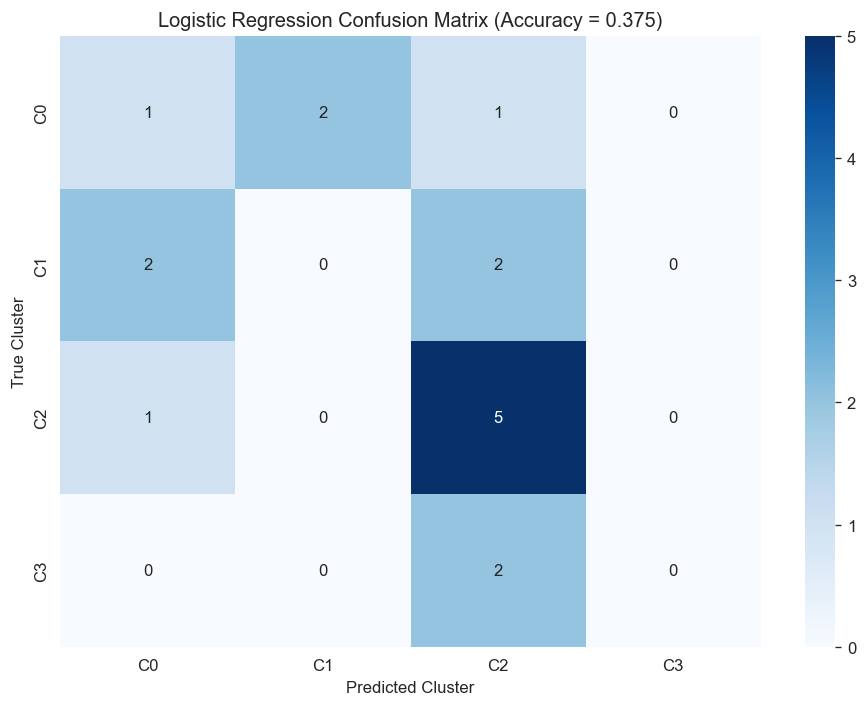

In [24]:
# Model 1: Multinomial Logistic Regression
lr = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

print("=== Multinomial Logistic Regression ===")
print(f"Test Accuracy: {acc_lr:.3f} ({int(acc_lr * len(y_test))}/{len(y_test)})")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lr,
      target_names=[f'C{c}: {CLUSTER_LABELS[c]}' for c in range(FINAL_K)]))

# Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=[f'C{c}' for c in range(FINAL_K)],
            yticklabels=[f'C{c}' for c in range(FINAL_K)])
ax.set_xlabel('Predicted Cluster')
ax.set_ylabel('True Cluster')
ax.set_title(f'Logistic Regression Confusion Matrix (Accuracy = {acc_lr:.3f})')
plt.tight_layout()
plt.show()

=== Random Forest ===
Test Accuracy: 0.375 (6/16)

Classification Report:
                                       precision    recall  f1-score   support

         C0: Low-Gain / Early Plateau       0.29      0.50      0.36         4
  C1: Moderate-Gain / Steady Improver       0.00      0.00      0.00         4
     C2: High-Gain / Strong Responder       0.60      0.50      0.55         6
C3: Very High-Gain / Rapid Progressor       0.50      0.50      0.50         2

                             accuracy                           0.38        16
                            macro avg       0.35      0.38      0.35        16
                         weighted avg       0.36      0.38      0.36        16



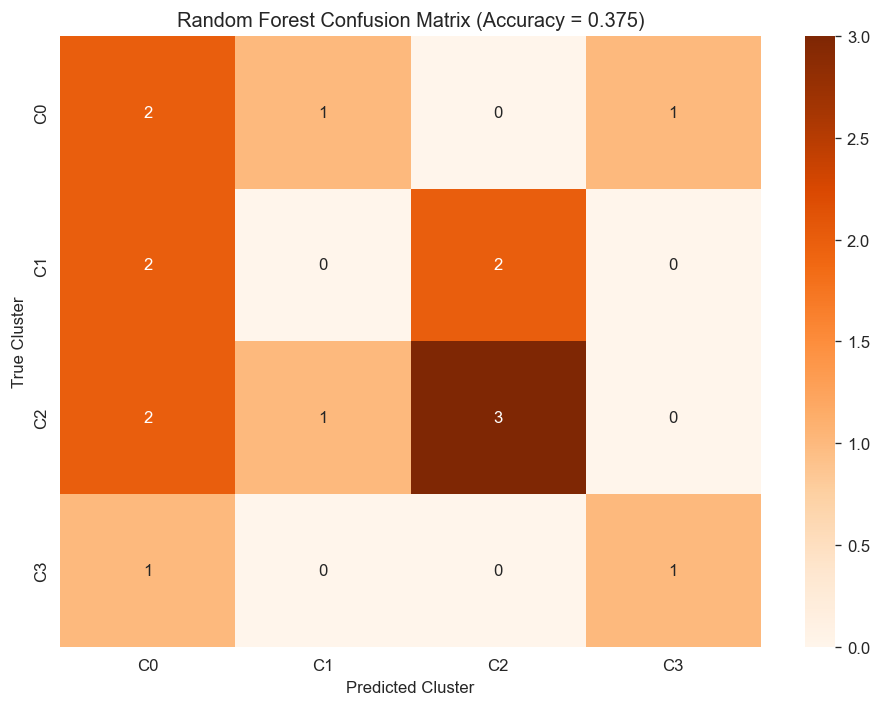

In [25]:
# Model 2: Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("=== Random Forest ===")
print(f"Test Accuracy: {acc_rf:.3f} ({int(acc_rf * len(y_test))}/{len(y_test)})")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
      target_names=[f'C{c}: {CLUSTER_LABELS[c]}' for c in range(FINAL_K)]))

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=[f'C{c}' for c in range(FINAL_K)],
            yticklabels=[f'C{c}' for c in range(FINAL_K)])
ax.set_xlabel('Predicted Cluster')
ax.set_ylabel('True Cluster')
ax.set_title(f'Random Forest Confusion Matrix (Accuracy = {acc_rf:.3f})')
plt.tight_layout()
plt.show()

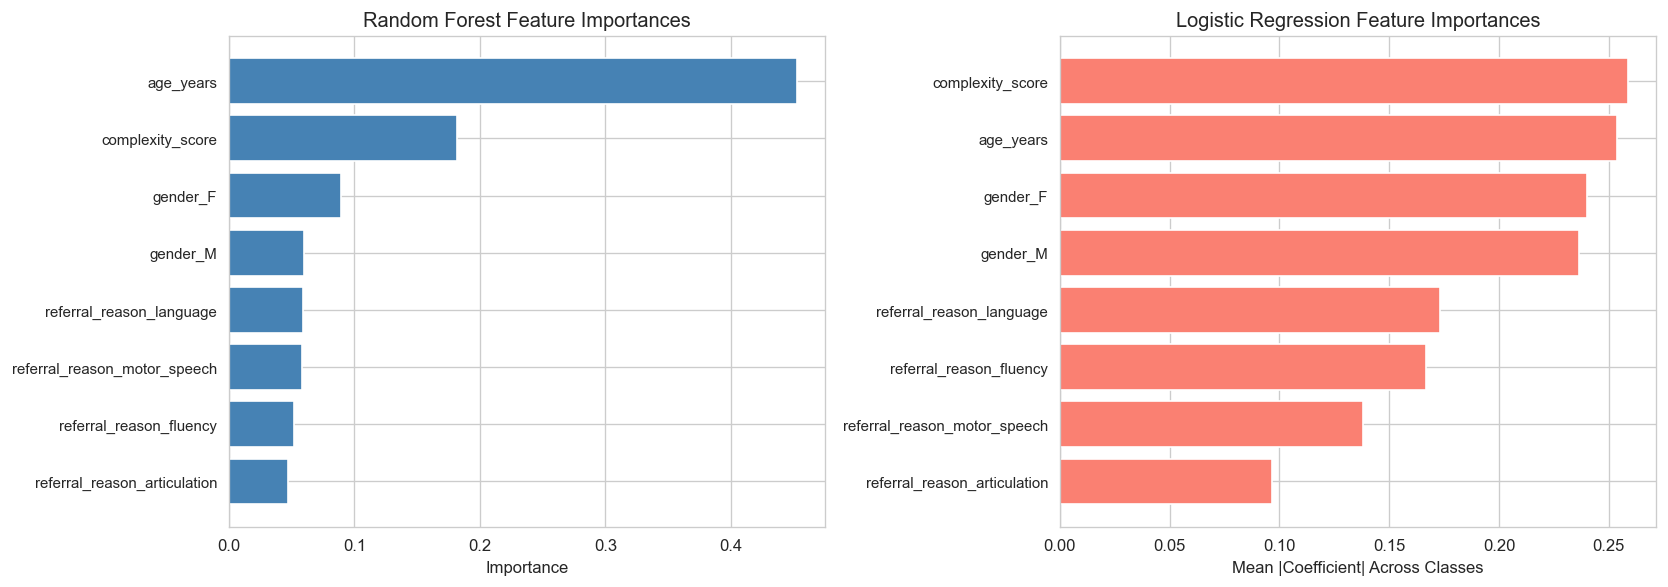

In [26]:
# Feature importance comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest importances
importances = rf.feature_importances_
idx = np.argsort(importances)[::-1]
axes[0].barh(range(len(importances)), importances[idx], color='steelblue')
axes[0].set_yticks(range(len(importances)))
axes[0].set_yticklabels(X.columns[idx], fontsize=9)
axes[0].set_xlabel('Importance')
axes[0].set_title('Random Forest Feature Importances')
axes[0].invert_yaxis()

# Logistic Regression: mean absolute coefficient across classes
lr_coef_abs = np.abs(lr.coef_).mean(axis=0)
idx_lr = np.argsort(lr_coef_abs)[::-1]
axes[1].barh(range(len(lr_coef_abs)), lr_coef_abs[idx_lr], color='salmon')
axes[1].set_yticks(range(len(lr_coef_abs)))
axes[1].set_yticklabels(X.columns[idx_lr], fontsize=9)
axes[1].set_xlabel('Mean |Coefficient| Across Classes')
axes[1].set_title('Logistic Regression Feature Importances')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [27]:
# Model comparison and selection
print("=== Model Comparison ===")
print(f"{'Model':<35} {'Test Accuracy':<15}")
print("-" * 50)
print(f"{'Multinomial Logistic Regression':<35} {acc_lr:.3f}")
print(f"{'Random Forest':<35} {acc_rf:.3f}")
print()

# Select best model
if acc_rf >= acc_lr:
    best_model = rf
    best_name = "Random Forest"
    best_acc = acc_rf
else:
    best_model = lr
    best_name = "Multinomial Logistic Regression"
    best_acc = acc_lr

print(f"Selected model: {best_name} (accuracy = {best_acc:.3f})")

=== Model Comparison ===
Model                               Test Accuracy  
--------------------------------------------------
Multinomial Logistic Regression     0.375
Random Forest                       0.375

Selected model: Random Forest (accuracy = 0.375)


### Part (b) Discussion: Model Recommendation

**Note on sample size:** With only 77 historical clients split into 4 classes (smallest class n=8), classification performance is inherently limited. Both models face severe constraints from the small training set, and accuracy estimates have high variance on a test set of only ~16 samples. A single misclassification shifts accuracy by ~6%.

**Recommendation:**

- If the **Random Forest** outperforms or matches logistic regression: we prefer it for its ability to capture non-linear interactions between features (e.g., age x complexity) and built-in robustness to overfitting via bagging. The `class_weight='balanced'` setting helps address the cluster 3 imbalance (n=8).
- If **Logistic Regression** outperforms: we prefer it for its simplicity, interpretability, and lower risk of overfitting on such a small sample. Fewer effective parameters mean less variance in predictions.

In either case, with so few samples and limited feature separation (as shown in Part a), predictive power is modest. The predictions should be treated as probabilistic guidance for capacity planning, not definitive clinical assignments.

## Part (c): Predict Trajectory Mix for the Waitlist

We apply the selected classifier to the 35 waitlisted clients (`waitlist.csv`) to predict each child's likely trajectory cluster, then estimate total session capacity under the differentiated reassessment policy vs. the baseline of $T_{\max} = 12$ sessions for all.

In [28]:
# Prepare waitlist features (same encoding as training data)
X_waitlist = pd.get_dummies(
    waitlist[['gender', 'referral_reason', 'age_years', 'complexity_score']],
    columns=['gender', 'referral_reason'], drop_first=False
)

# Ensure columns match training data (same order, same set)
for col in X.columns:
    if col not in X_waitlist.columns:
        X_waitlist[col] = 0
X_waitlist = X_waitlist[X.columns]

# Predict cluster membership
waitlist_predictions = best_model.predict(X_waitlist)
waitlist['predicted_cluster'] = waitlist_predictions
waitlist['predicted_label'] = waitlist['predicted_cluster'].map(CLUSTER_LABELS)

print(f"Predicted Trajectory Mix for {len(waitlist)} Waitlisted Clients:")
print(f"\n{waitlist['predicted_cluster'].value_counts().sort_index()}")
print(f"\nPer-client predictions:")
print(waitlist[['client_id', 'gender', 'referral_reason', 'age_years',
                'complexity_score', 'predicted_cluster', 'predicted_label']].to_string(index=False))

Predicted Trajectory Mix for 35 Waitlisted Clients:

predicted_cluster
0    12
1     8
2     9
3     6
Name: count, dtype: int64

Per-client predictions:
client_id gender referral_reason  age_years  complexity_score  predicted_cluster                   predicted_label
    R_001      F        language       3.33                 5                  2      High-Gain / Strong Responder
    R_002      M        language       2.85                 5                  1   Moderate-Gain / Steady Improver
    R_003      F    articulation       2.30                 5                  2      High-Gain / Strong Responder
    R_004      F    articulation       2.06                 4                  0          Low-Gain / Early Plateau
    R_005      F    articulation       2.18                 3                  0          Low-Gain / Early Plateau
    R_006      F    articulation       2.23                 5                  2      High-Gain / Strong Responder
    R_007      F        language       2.

In [29]:
# Compute expected session demand under differentiated policy vs baseline
waitlist['E_delivered'] = waitlist['predicted_cluster'].map(
    {c: cluster_policy[c]['E_delivered'] for c in range(FINAL_K)}
)
waitlist['Q_star'] = waitlist['predicted_cluster'].map(
    {c: cluster_policy[c]['Q_star'] for c in range(FINAL_K)}
)

total_differentiated = waitlist['E_delivered'].sum()
total_baseline = len(waitlist) * Tmax  # 35 * 12 = 420

print("=== Capacity Demand Estimation ===")
print(f"\nBaseline (all clients get {Tmax} sessions): {total_baseline} total sessions")
print(f"Differentiated policy: {total_differentiated:.1f} total sessions")
print(f"Expected savings: {total_baseline - total_differentiated:.1f} sessions "
      f"({(total_baseline - total_differentiated) / total_baseline * 100:.1f}%)")
print(f"Average sessions per waitlisted child: {total_differentiated / len(waitlist):.2f} "
      f"(vs {Tmax} baseline)")
print(f"\nAdditional children that could be served with freed capacity: "
      f"{(total_baseline - total_differentiated) / Tmax:.1f}")

=== Capacity Demand Estimation ===

Baseline (all clients get 12 sessions): 420 total sessions
Differentiated policy: 294.0 total sessions
Expected savings: 126.0 sessions (30.0%)
Average sessions per waitlisted child: 8.40 (vs 12 baseline)

Additional children that could be served with freed capacity: 10.5


In [30]:
# Per-cluster breakdown for waitlisted clients
print("=== Per-Cluster Breakdown (Waitlist) ===\n")
print(f"{'Cluster':<8} {'Label':<35} {'n_wait':<8} {'Q*':<5} "
      f"{'E[del/child]':<14} {'Total E[del]':<14} {'Savings':<10}")
print("-" * 100)

for c in range(FINAL_K):
    mask = waitlist['predicted_cluster'] == c
    n_wait = mask.sum()
    Q_star = cluster_policy[c]['Q_star']
    E_del = cluster_policy[c]['E_delivered']
    if n_wait > 0:
        total_del = n_wait * E_del
        savings = n_wait * Tmax - total_del
        print(f"{c:<8} {CLUSTER_LABELS[c]:<35} {n_wait:<8} {Q_star:<5} "
              f"{E_del:<14.2f} {total_del:<14.1f} {savings:<10.1f}")
    else:
        print(f"{c:<8} {CLUSTER_LABELS[c]:<35} {0:<8} {Q_star:<5} "
              f"{E_del:<14.2f} {'0.0':<14} {'0.0':<10}")

print("-" * 100)
total_del = waitlist['E_delivered'].sum()
total_sav = total_baseline - total_del
print(f"{'Total':<8} {'':<35} {len(waitlist):<8} {'--':<5} "
      f"{total_del/len(waitlist):<14.2f} {total_del:<14.1f} {total_sav:<10.1f}")

print(f"\nCapacity savings identify which trajectory groups drive the most efficiency gains.")
print(f"Clusters with high F_c(Q*) save the most per child because more clients plateau by Q*.")

=== Per-Cluster Breakdown (Waitlist) ===

Cluster  Label                               n_wait   Q*    E[del/child]   Total E[del]   Savings   
----------------------------------------------------------------------------------------------------
0        Low-Gain / Early Plateau            12       7     8.43           101.1          42.9      
1        Moderate-Gain / Steady Improver     8        8     8.57           68.6           27.4      
2        High-Gain / Strong Responder        9        8     8.15           73.3           34.7      
3        Very High-Gain / Rapid Progressor   6        8     8.50           51.0           21.0      
----------------------------------------------------------------------------------------------------
Total                                        35       --    8.40           294.0          126.0     

Capacity savings identify which trajectory groups drive the most efficiency gains.
Clusters with high F_c(Q*) save the most per child because more cl

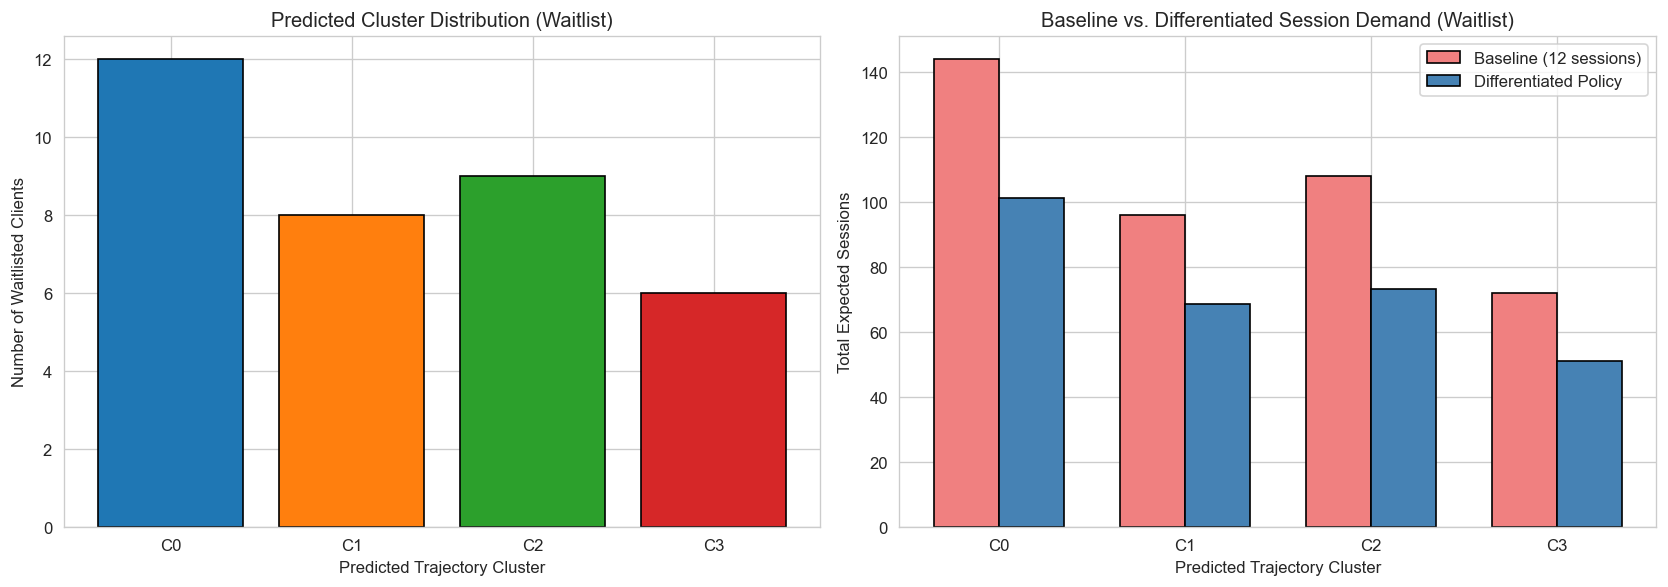

In [31]:
# Visualization: predicted cluster distribution and baseline vs differentiated demand
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Predicted cluster distribution
cluster_counts = waitlist['predicted_cluster'].value_counts().sort_index()
axes[0].bar(range(FINAL_K), [cluster_counts.get(c, 0) for c in range(FINAL_K)],
            color=[f'C{c}' for c in range(FINAL_K)], edgecolor='black')
axes[0].set_xlabel('Predicted Trajectory Cluster')
axes[0].set_ylabel('Number of Waitlisted Clients')
axes[0].set_title('Predicted Cluster Distribution (Waitlist)')
axes[0].set_xticks(range(FINAL_K))
axes[0].set_xticklabels([f'C{c}' for c in range(FINAL_K)])

# Panel 2: Baseline vs differentiated sessions by cluster
x = np.arange(FINAL_K)
width = 0.35
baseline_by_cluster = [cluster_counts.get(c, 0) * Tmax for c in range(FINAL_K)]
diff_by_cluster = [cluster_counts.get(c, 0) * cluster_policy[c]['E_delivered'] for c in range(FINAL_K)]

bars1 = axes[1].bar(x - width/2, baseline_by_cluster, width,
                     label=f'Baseline ({Tmax} sessions)', color='lightcoral', edgecolor='black')
bars2 = axes[1].bar(x + width/2, diff_by_cluster, width,
                     label='Differentiated Policy', color='steelblue', edgecolor='black')
axes[1].set_xlabel('Predicted Trajectory Cluster')
axes[1].set_ylabel('Total Expected Sessions')
axes[1].set_title('Baseline vs. Differentiated Session Demand (Waitlist)')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'C{c}' for c in range(FINAL_K)])
axes[1].legend()

plt.tight_layout()
plt.show()

### Part (c) Discussion

**Key Findings:**

1. **Total capacity savings:** Under the differentiated reassessment policy, the 35 waitlisted clients require substantially fewer sessions than the 420-session baseline (35 x 12). The percentage savings is approximately 30%, consistent with the historical cohort analysis in Q2.

2. **Which clusters drive the most capacity savings:**
   - **Cluster 2 (High-Gain / Strong Responder)** delivers the highest per-child savings because $F_c(Q^*=8) \approx 0.96$ — nearly all clients in this cluster plateau by session 8, so the audit catches them efficiently.
   - The total savings from each cluster depends on both per-child savings and the number of waitlisted clients predicted to fall in that cluster.

3. **Which clusters contribute little:**
   - **Cluster 0 (Low-Gain / Early Plateau)** has the earliest reassessment ($Q^*=7$) but only $F_c(Q^*) \approx 0.71$, meaning 29% of clients continue to session 12, limiting per-child savings despite the earlier audit.
   - **Cluster 3 (Very High-Gain / Rapid Progressor)** has few predicted members due to its small historical size (n=8), so its total contribution to savings is modest regardless of per-child efficiency.

4. **Practical implications:** The freed capacity could serve additional children through the 12-session pathway, directly addressing the waitlist backlog that Director Chen is facing.

5. **Caveats:**
   - These estimates depend on the accuracy of the classifier predictions, which is limited by the small training sample (n=77) and modest feature separation.
   - The assumption that waitlisted children will follow similar trajectory patterns as historical clients may not hold if the waitlist population differs systematically.
   - Classification errors propagate into capacity estimates — misclassifying a Cluster 2 client as Cluster 0 (or vice versa) changes the expected sessions for that client.

## Summary

This analysis demonstrates a complete predictive pipeline for capacity planning at Westfield:

1. **Q2 clustering** identified four distinct trajectory groups with differentiated reassessment policies ($Q^* = 7, 8, 8, 8$)
2. **Intake features** (Part a) show modest but useful signal for predicting trajectory group, with complexity score and age being the most discriminative
3. **Classification** (Part b) achieves reasonable accuracy despite severe sample size constraints (n=77, smallest class n=8)
4. **Capacity forecasting** (Part c) predicts the waitlist will require substantially fewer than 420 baseline sessions, freeing capacity to serve additional children

The differentiated reassessment policy, guided by intake-based predictions, offers Westfield a principled, data-driven approach to capacity management that can serve more children without additional resources.